# Task 2: Exploratory Data Analysis (EDA) - UNSW-NB15
This notebook performs EDA on the cleaned UNSW-NB15 dataset: summary statistics, distributions, class imbalance, attack categories, correlation analysis, and visualizations.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly

**Cell 1:** Import libraries and set visual style.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import skew, kurtosis

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
%matplotlib inline

**Cell 2:** Load cleaned training set.

In [2]:
train_df = pd.read_csv('UNSW_NB15_training_cleaned.csv')
print(f"Dataset shape: {train_df.shape}")

Dataset shape: (82332, 185)


**Cell 3:** Basic info and missing values check.

In [3]:
train_df.info()
print(f"\nMissing values: {train_df.isnull().sum().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Columns: 185 entries, id to state_encoded
dtypes: bool(142), float64(42), str(1)
memory usage: 38.2 MB

Missing values: 0


**Cell 4:** Summary statistics for numeric features (mean, std, quartiles, skewness, kurtosis).

In [4]:
num_features = ['dur', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 
                'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit']

desc = train_df[num_features].describe().T
desc['skew'] = skew(train_df[num_features])
desc['kurtosis'] = kurtosis(train_df[num_features])
print("Summary statistics for numeric features:")
print(desc[['mean', 'std', '25%', '50%', '75%', 'skew', 'kurtosis']])

Summary statistics for numeric features:
                mean       std       25%       50%       75%      skew  \
dur     6.628004e-17  1.000006 -0.709119 -0.684623  0.537957  1.262663   
sbytes -4.971003e-17  1.000006 -0.805780 -0.389652  0.349472  1.145527   
dbytes -2.209335e-17  1.000006 -0.714084 -0.510699  0.378253  1.204683   
rate    1.657001e-16  1.000006 -0.728222 -0.699881  0.472669  1.122504   
sttl   -4.418669e-17  1.000006 -1.171948  0.719440  0.719440 -0.690369   
dttl    0.000000e+00  1.000006 -0.820395 -0.571824  1.339599  0.575197   
sload  -2.209335e-17  1.000006 -0.706879 -0.696708  0.464042  1.174020   
dload  -2.209335e-16  1.000006 -0.684990 -0.553081  0.305015  1.126489   
sinpkt  2.209335e-17  1.000006 -0.695663 -0.684776  0.559415  1.295507   
dinpkt -4.418669e-17  1.000006 -0.657691 -0.657495  0.583435  1.298562   
sjit   -6.628004e-17  1.000006 -0.685138 -0.678522  0.523525  1.270877   
djit    2.209335e-17  1.000006 -0.684375 -0.684375  0.487130  1.280545 

**Cell 5:** Target variable distribution (class imbalance).

label
0.0    37000
1.0    45332
Name: count, dtype: int64
82332
Attack percentage: 55.06%


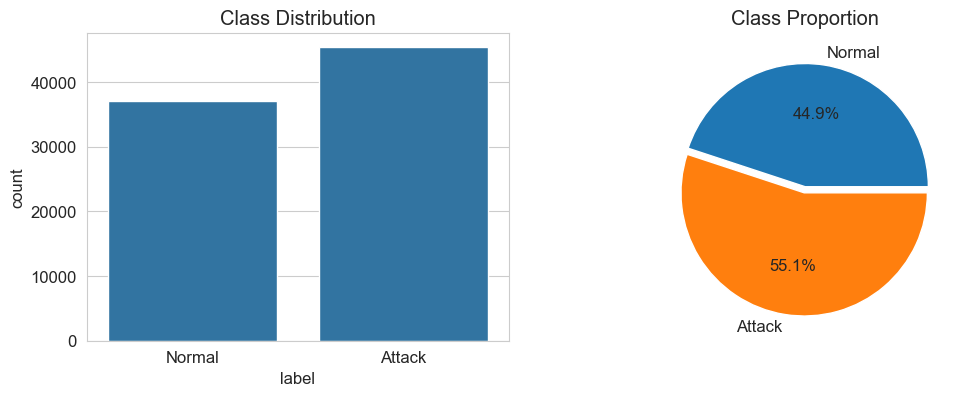

In [15]:
# Count of normal vs attack
label_counts = train_df['label'].value_counts().sort_index()
print(label_counts)
print(len(train_df))
print(f"Attack percentage: {label_counts[1]/len(train_df)*100:.2f}%")

# Visual
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='label', data=train_df, ax=ax[0])
ax[0].set_title('Class Distribution')
ax[0].set_xticks([0, 1])               # <-- add this line
ax[0].set_xticklabels(['Normal', 'Attack'])
ax[1].pie(label_counts, labels=['Normal', 'Attack'], autopct='%1.1f%%', explode=(0, 0.05))
ax[1].set_title('Class Proportion')
plt.show()

**Cell 6:** Attack categories distribution (if `attack_cat` exists).

Attack category counts:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


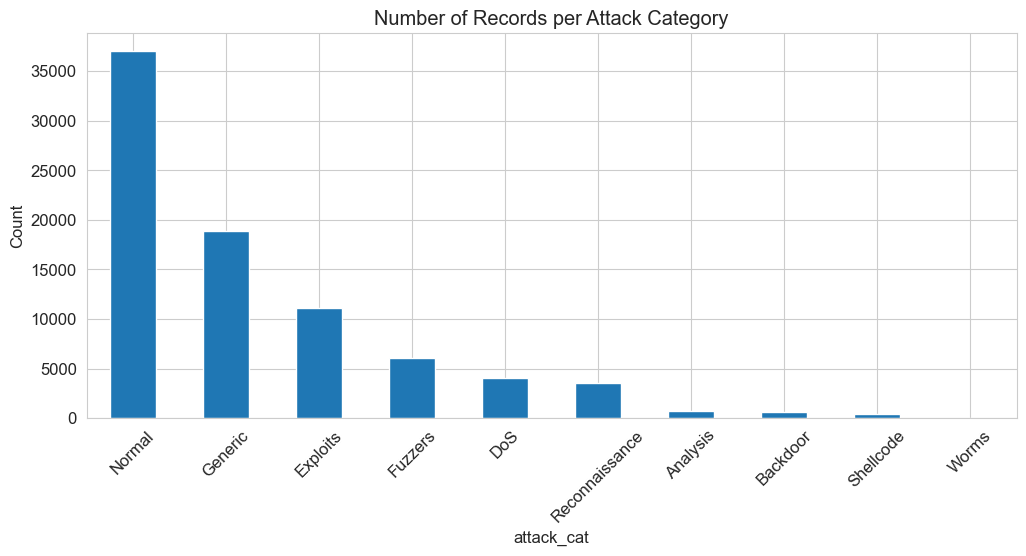

In [6]:
if 'attack_cat' in train_df.columns:
    attack_counts = train_df['attack_cat'].value_counts()
    print("Attack category counts:")
    print(attack_counts)
    
    plt.figure(figsize=(12,5))
    attack_counts.plot(kind='bar')
    plt.title('Number of Records per Attack Category')
    plt.xticks(rotation=45)
    plt.ylabel('Count')
    plt.show()
else:
    print("Column 'attack_cat' not found in the dataset.")

**Cell 7:** Histograms of key numeric features.

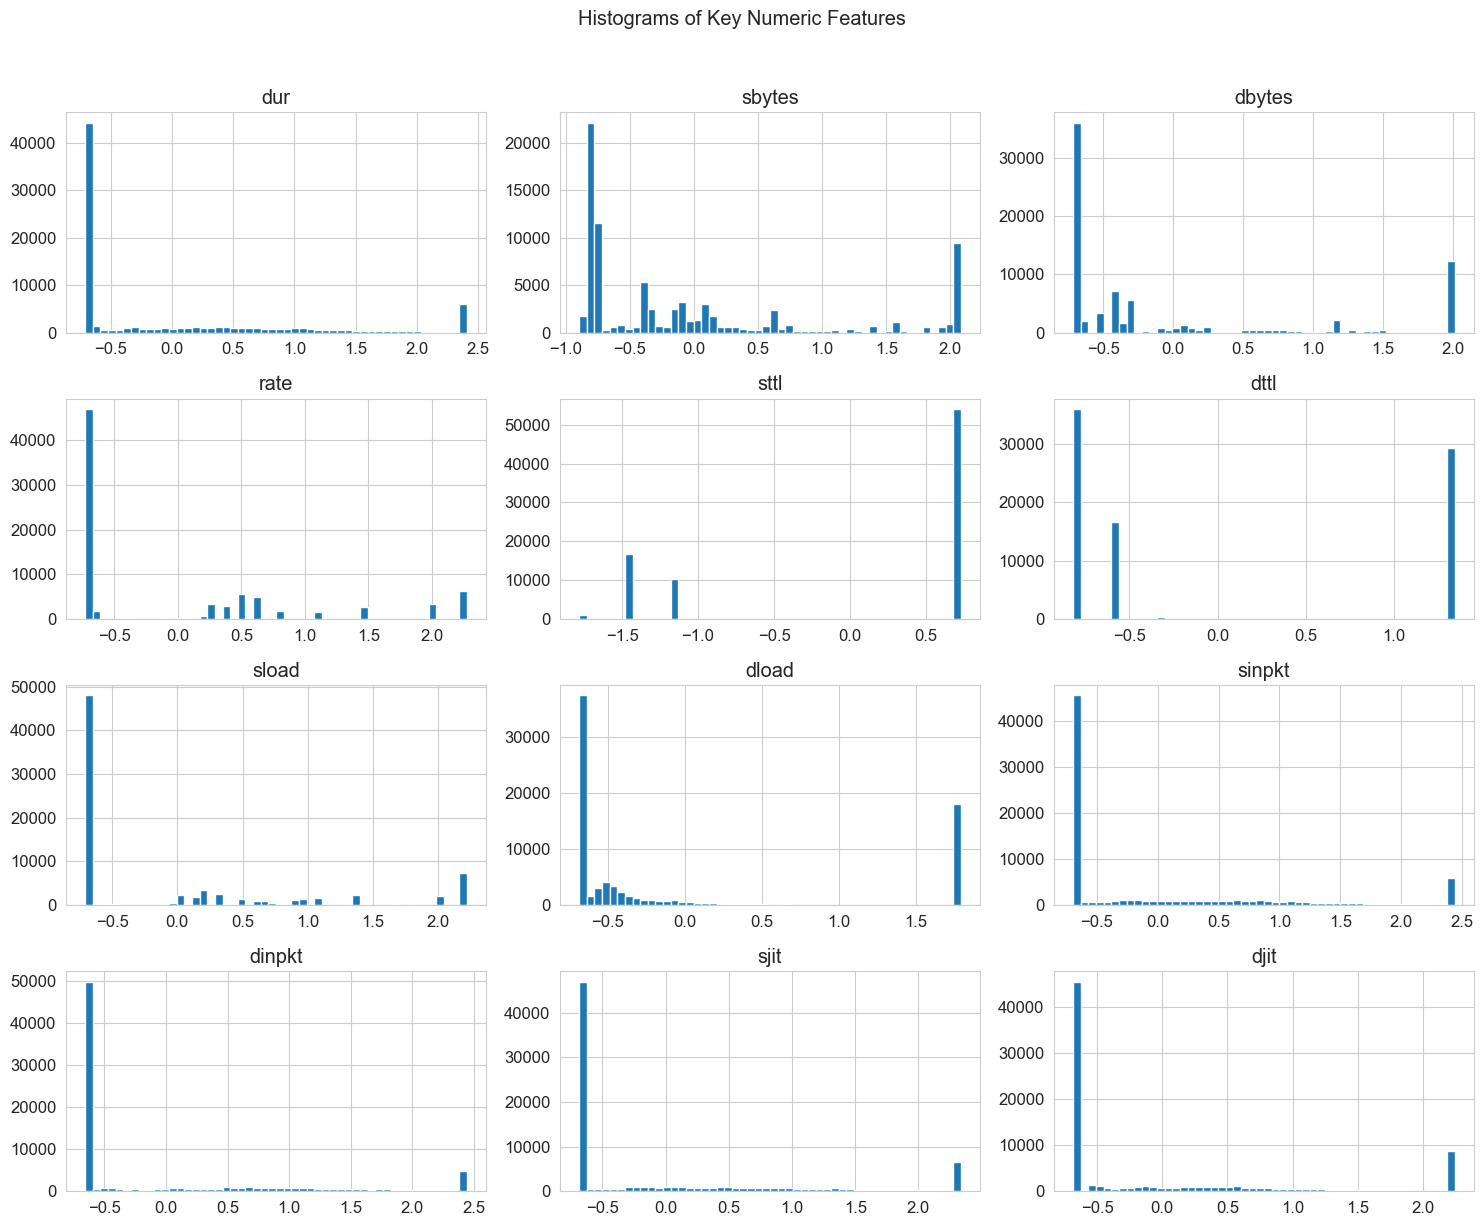

In [7]:
train_df[num_features].hist(bins=50, figsize=(15,12))
plt.suptitle('Histograms of Key Numeric Features', y=1.02)
plt.tight_layout()
plt.show()

**Cell 8:** Boxplots of numeric features (after capping).

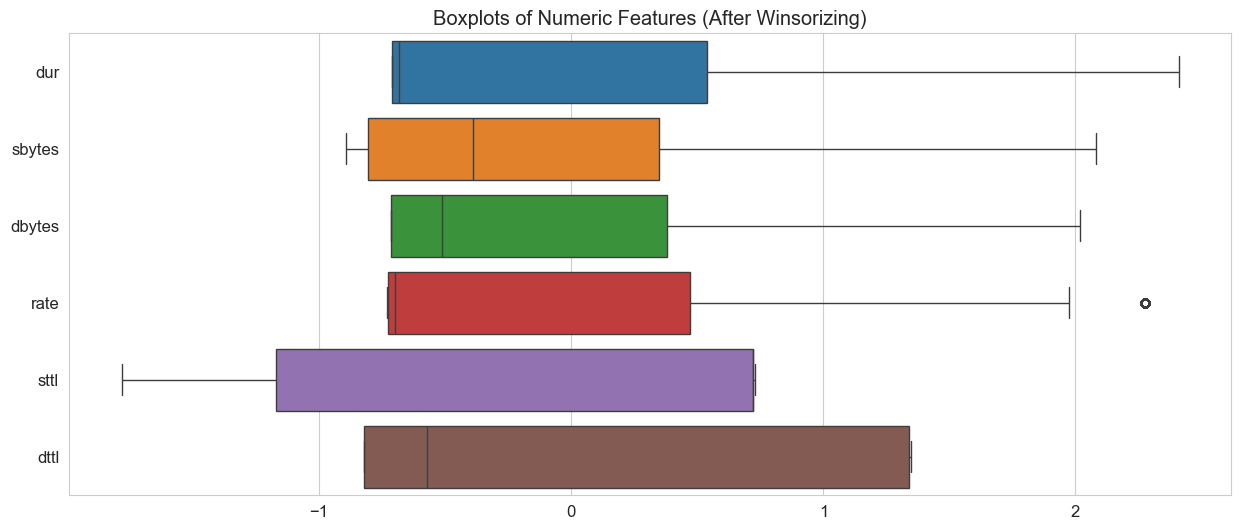

In [8]:
plt.figure(figsize=(15,6))
sns.boxplot(data=train_df[num_features[:6]], orient='h')
plt.title('Boxplots of Numeric Features (After Winsorizing)')
plt.show()

**Cell 9:** Correlation matrix heatmap.

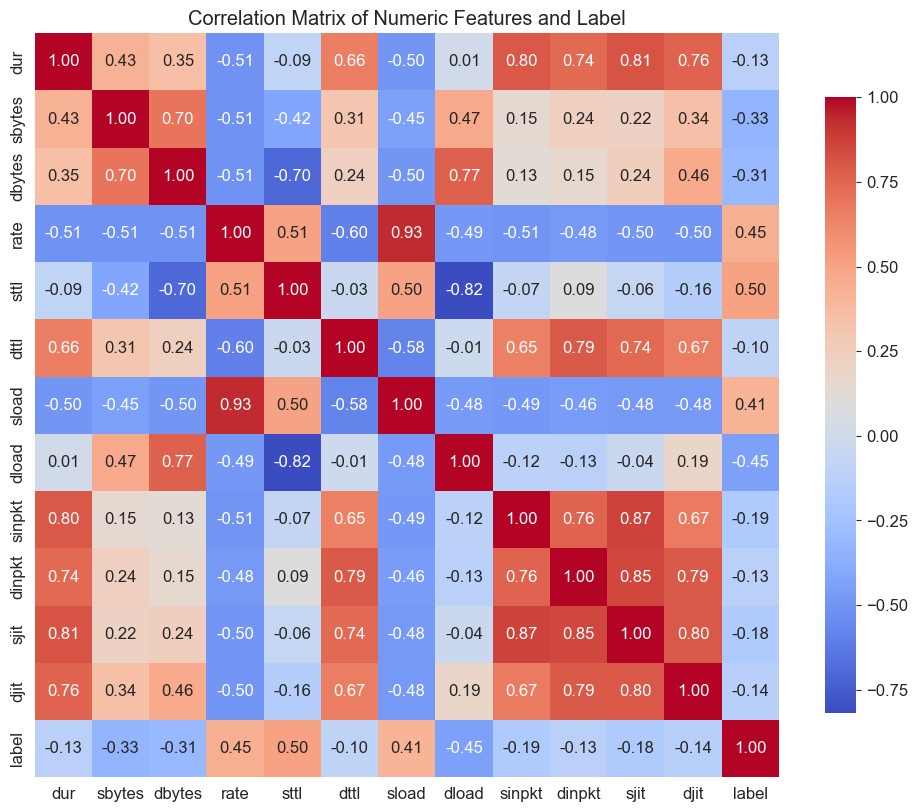

In [9]:
corr_subset = num_features + ['label']
corr_matrix = train_df[corr_subset].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Numeric Features and Label')
plt.show()

**Cell 10:** Pairplot for a subset of features (sampled).

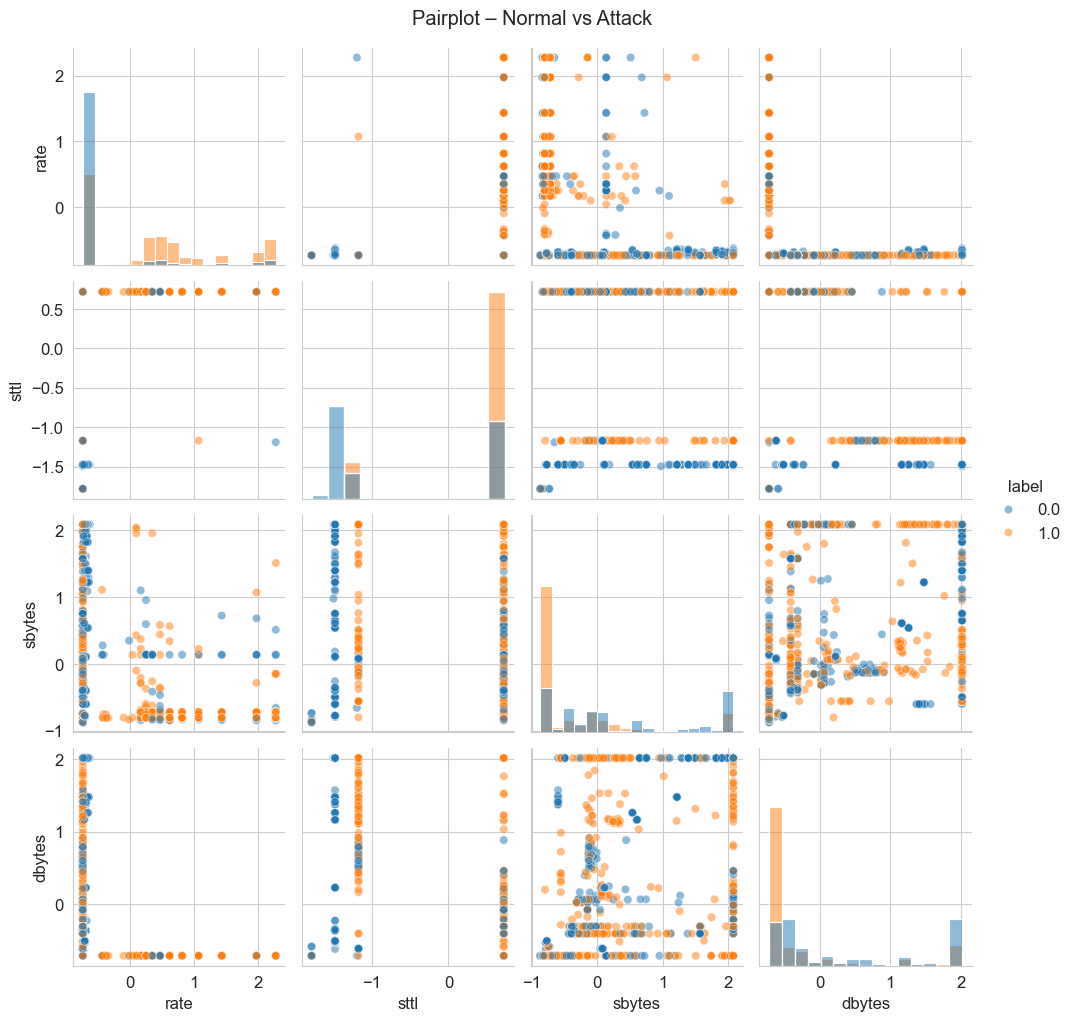

In [10]:
sample_features = ['rate', 'sttl', 'sbytes', 'dbytes', 'label']
sample_df = train_df[sample_features].sample(n=2000, random_state=42)
sns.pairplot(sample_df, hue='label', diag_kind='hist', plot_kws={'alpha':0.5})
plt.suptitle('Pairplot – Normal vs Attack', y=1.02)
plt.show()

**Cell 11:** Scatter plots for anomaly detection.

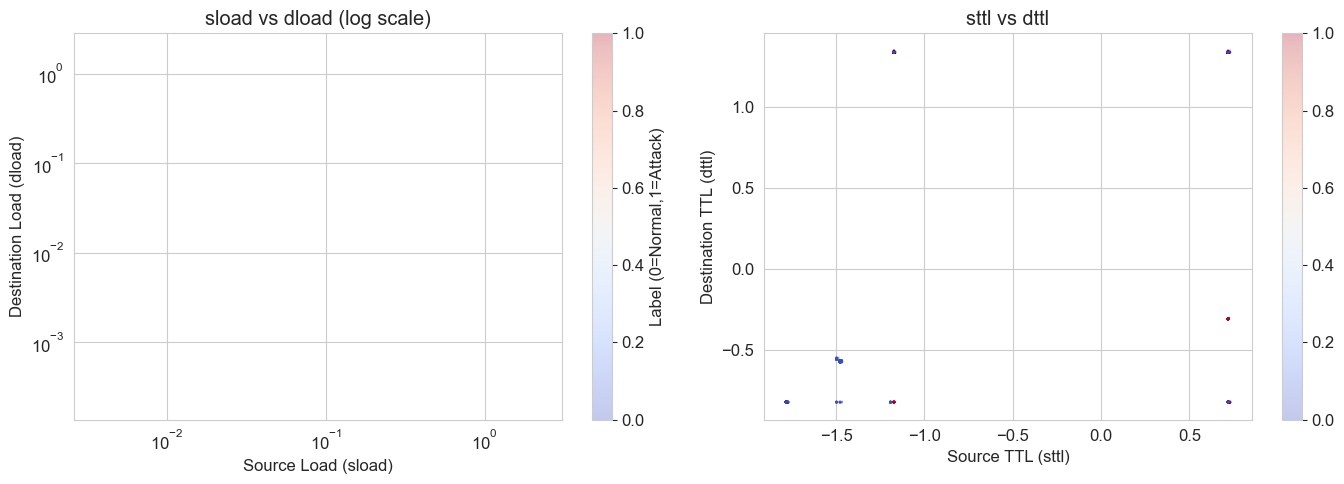

In [11]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
# Scatter 1: sload vs dload
sc = axes[0].scatter(train_df['sload'], train_df['dload'], c=train_df['label'], 
                     cmap='coolwarm', alpha=0.3, s=1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Source Load (sload)')
axes[0].set_ylabel('Destination Load (dload)')
axes[0].set_title('sload vs dload (log scale)')
plt.colorbar(sc, ax=axes[0], label='Label (0=Normal,1=Attack)')

# Scatter 2: sttl vs dttl
sc2 = axes[1].scatter(train_df['sttl'], train_df['dttl'], c=train_df['label'], 
                      cmap='coolwarm', alpha=0.3, s=1)
axes[1].set_xlabel('Source TTL (sttl)')
axes[1].set_ylabel('Destination TTL (dttl)')
axes[1].set_title('sttl vs dttl')
plt.colorbar(sc2, ax=axes[1])
plt.tight_layout()
plt.show()

## Summary

1. **Class imbalance**: The dataset exhibits only a slight class imbalance `(55.1% attack vs 44.9% normal)`. Severe resampling techniques are likely unnecessary, but class-weighted learning may still be beneficial.  

2. **Skewed features**: `sbytes`, `dbytes`, `rate`, `sload`, `dload` are highly right-skewed; log transformation may help.  

3. **Attack categories**: `Generic`, `Exploits`, `Fuzzers`, `DoS`, and `Reconnaissance` are the most common attack types, while other categories are less frequent.  

4. **Correlations**: Most numeric features show weak linear correlation with the target, suggesting non-linear models may perform better.  

5. **Anomaly patterns**: Attack samples tend to exhibit higher load values and more varied TTL values compared to normal traffic.  

6. **Next steps**: Feature engineering (log transforms), handling class imbalance, and evaluating tree-based or neural network models.  